In [406]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression

# Cinética de Procesos (Sesión 02)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# Ejemplo práctico

<center>

***Evaluación del rendimiento de desulfuración del acero líquido durante el proceso de metalurgia secundaria.***

</center>

## Generación de datos de proceso artificiales

In [407]:
def desulf_1st(t:float, wS:float, k:float, wSi:float) -> float:
    return -k*(wS-wSi)

In [ ]:
# definir tiempos para integración y constantes
k = 0.05 # [min-1]
wS0 = 0.04 # [wt%]
wSi = 0.005 # [wt%]
t_eval = np.linspace(0, 60, 121)

nHeats = 200
nSamples = 4
data = np.empty(shape=(nSamples*nHeats, 4))

for ii in range(nHeats):
    # ruido artificial
    noise_k = np.random.normal(0, 0.1*k)
    noise_wS0 = np.random.normal(0, 0.1*wS0)
    noise_wSi = np.random.normal(0, 0.1*wSi)

    # solución de la ecuación diferencial
    sol = solve_ivp(
        desulf_1st,
        t_span = (t_eval[0], t_eval[-1]),
        y0 = [wS0 + noise_wS0],
        args=(k+noise_k, max(wSi+noise_wSi, 0)),
        t_eval = t_eval
    )

    ### simulación de toma de muestras (nSamples muestras por colada)
    for samp in range(nSamples):
        ind0 = samp * len(t_eval) // nSamples
        tind = min(ind0 + np.random.randint(0, 25), len(t_eval)) # tiempos con ligero desface
        data[nSamples*ii + samp, :] = [ii, samp, sol.t[tind], np.round(sol.y[0][tind], 4)]
    
    
# Crear DataFrame con los datos de proceso artificiales    
df = pd.DataFrame(data=data, columns=["heat", "sample", "t", "S"])
df = df.astype({"heat": "int32", "sample": "int32"})
display(df)

,heat,sample,t,S
0,0,0,12.0,0.0252
1,0,1,15.5,0.0221
2,0,2,30.5,0.0133
3,0,3,55.5,0.0074
4,1,0,2.5,0.0402
...,...,...,...,...
1995,498,3,55.0,0.0064
1996,499,0,6.0,0.0282
1997,499,1,27.0,0.0129
1998,499,2,36.0,0.0101


## Análisis de datos de proceso

**¿Qué estrategias utilizar?**

- Visualización de datos crudos.

- Fundamentos teóricos:
    - Revisión bibliográfica.
    - Consenso general: la reacción de desulfuración de un acero es de primer orden.

- Construcción de modelos (determinación de parámetros):
    - Métodos gráficos.
    - Métodos numéricos.


### Visualización de datos crudos

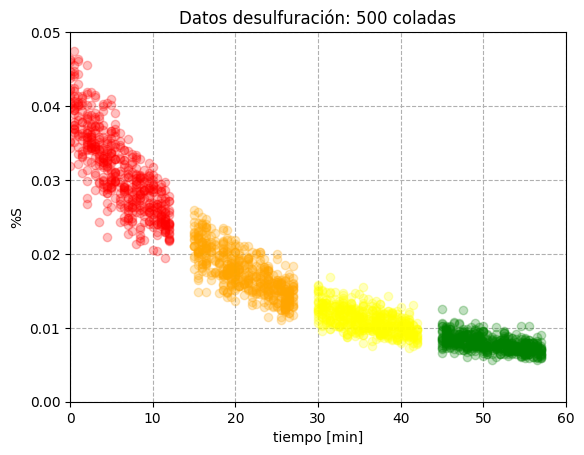

In [409]:
# visualización de los datos de proceso
fig, ax = plt.subplots()

unique_samples = pd.unique(df["sample"])
unique_colors = ["red", "orange", "yellow", "green"]
for sample, color in zip(unique_samples, unique_colors):
    dfr = df[df["sample"] == sample]
    ax.plot(dfr["t"], dfr["S"], ls='', marker='o', color=color, alpha=0.25)
ax.set(
    xlabel='tiempo [min]',
    ylabel='%S',
    xlim = (0, 60),
    ylim = (0, 0.05),
    title = f"Datos desulfuración: {nHeats} coladas"
)
ax.grid(ls='--')
plt.show()

### Fundamentos teóricos

#### Reacción de desulfuración

**Reacción de desulfuración:**

En la refinación de acero, la desulfuración del metal se lleva a cabo por medio de reacciones entre el metal y escoria. Específicamente, la reacción de desulfuración es una reacción de intercambio iónico de azufre entre metal y escoria, que ocurre en la interface metal-escoria:

$$ \mathrm{\left[S \right] + \left( O^{2-} \right) = \left( S^{2-} \right) + \left[ O \right]}$$

$$ K_{\mathrm{S}} = \underbrace{\frac{ \left( a_{S^{2-}}\right) }{ \left( a_{O^{2-}}\right)  }}_{no \, medible} \,\, \underbrace{\frac{\left[h_O\right] }{\left[h_S\right]}}_{medible}$$

donde:
- $a_{S^{2-}}$ y $a_{O^{2-}}$, son las actividades de los iones de azufre y oxígeno en la escoria (no medibles).
- $h_{O}$ y $h_{S}$, son las actividades Henrianas (1%wt) de oxígeno y azufre en el metal (medibles).

<div class="alert alert-success">

<center>

**Consenso general:** la reacción de desulfuración de un acero es de primer orden.

</center>

</div>

#### Cinética de primer orden (simplificada)

<div class="alert alert-warning">

**Hipótesis simplificadoras:** 

- La escoria tiene capacidad ***infinita*** para remover todo el azufre contenido en el metal.
- La reacción de desulfuración es irreversible.

</div>

$$\frac{d C_\mathrm{S}}{dt} = -k C_{\mathrm{S}}$$

$$-\int_{C_{\mathrm{S}}^{0}}^{\mathrm{C_{S}}} \frac{dC_{\mathrm{S}}}{C_{\mathrm{S}}} = k \int_{0}^{t} dt$$

$$\ln \frac{C_{\mathrm{S}}^{0}}{C_{\mathrm{S}}} =  kt$$

$$C_{\mathrm{S}} = C_{\mathrm{S}}^{0} \exp \left(-k t\right)$$

donde:
- $C_{\mathrm{S}}$, concentración de azufre en el metal, $[\mathrm{wt\%}]$.
- $C_{\mathrm{S}}^{0}$, concentración inicial de azufre en el metal, $[\mathrm{wt\%}]$.
- $k$, constante cinética de desulfuración, $[\mathrm{s^{-1}}]$.

In [410]:
def rate_law_1s(t, k, cA0):
    return cA0 * np.exp(-k*t)

#### Cinética de primer orden (un poco más realista)

<div class="alert alert-warning">


**Hipótesis simplificadoras:**

- La escoria tiene una capacidad limitada para remover el azufre en el metal. 
- La reacción de desulfuración es reversible.
- El nivel mínimo de azufre que se puede alcanzar en el metal, se puede calcular a partir de la composición del metal y escoria, asumiendo que se establece un equilibrio termodinámico en la interface metal-escoria.

</div>

$$\frac{d C_\mathrm{S}}{dt} = -k \left( C_{\mathrm{S}} - C_{\mathrm{S}}^{*} \right)$$

$$-\int_{C_{\mathrm{S}}^{0}}^{C_{\mathrm{S}}} \frac{dC_{\mathrm{S}}}{\left( C_{\mathrm{S}} - C_{\mathrm{S}}^{*} \right)} = k \int_{0}^{t} dt$$

$$\ln \frac{C_{\mathrm{S}}^{0} - C_{\mathrm{S}}^{*}}{C_{\mathrm{S}}-C_{\mathrm{S}}^{*}} =  kt$$

$$C_{\mathrm{S}} = \left(C_{\mathrm{S}}^{0} - C_{\mathrm{S}}^{*}\right) \exp \left(-k t \right) + C_{\mathrm{S}}^{*}$$

donde:
- $C_{\mathrm{S}}$, concentración de azufre en el metal, $[\mathrm{wt\%}]$.
- $C_{\mathrm{S}}^{0}$, concentración inicial de azufre en el metal, $[\mathrm{wt\%}]$.
- $C_{\mathrm{S}}^{*}$, concentración de azufre al equilibrio en la interface metal-escoria, $[\mathrm{wt\%}]$.
- $k$, constante cinética de desulfuración, $[\mathrm{s^{-1}}]$.

In [411]:
def rate_law_1r(t, k, cA0, cAe):
    return (cA0-cAe) * np.exp(-k*t) + cAe

### Construcción de modelos

#### Métodos gráficos

**¿Cómo estimar los valores de $C_{\mathrm{S}}^{0}$ y $C_{\mathrm{S}}^{*}$?**

- Análisis histórico de proceso.
- Implementar un criterio, e.g:
    - promedio de las muestras que se tomaron cerca del inicio y final del proceso.
    - mediana de las muestras que se tomaron cerca del inicio y final del proceso.
    - valores máximos y mínimos del proceso.
    - ¿otros?

In [412]:
# estimación de valores de cS0 y cSe
wS0, wSe = df[df["t"] <= 5]["S"].mean(), df[df["t"] >= 55]["S"].mean()
print(f"Cs0 = {wS0:8.4f} wt% | Cs* = {wSe:8.4f} wt%")

# datos
x = df['t'].to_numpy().reshape(-1, 1) # shape required for LinearRegression
y = np.log(wS0/ df['S']).to_numpy()

# regresión lineal (la pendiente corresponde a la constante cinética)
model1 = LinearRegression(fit_intercept=False)
model1.fit(x, y)
k1 = model1.coef_[0]
print(f"k = {k1:.4f} [1/min]")

Cs0 =   0.0357 wt% | Cs* =   0.0072 wt%
k = 0.0312 [1/min]


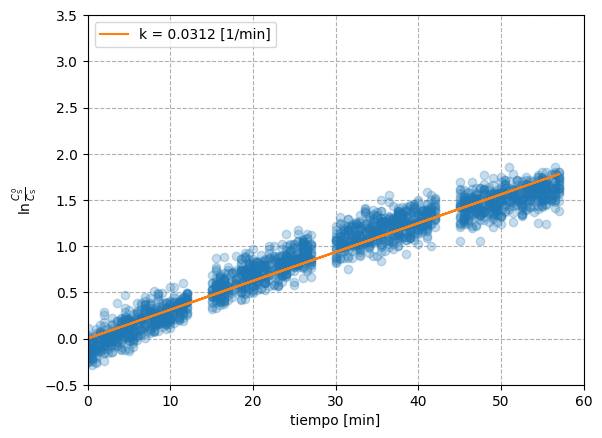

In [413]:
# visualización de datos

fig, ax = plt.subplots()

# plot
ax.plot(x, y, ls='', marker='o', alpha=0.25)
ax.plot(x, model1.predict(x), label=f"k = {k1:.4f} [1/min]")
ax.set(
    xlabel="tiempo [min]",
    ylabel=r"$\ln \frac{C_{\mathrm{S}}^{0}}{C_{\mathrm{S}}}$",
    xlim = (0, 60),
    ylim = (-0.5, 3.5)
)
ax.grid(ls='--')
ax.legend(loc='upper left')
plt.show()

#### Métodos numéricos

In [414]:
# data
x = df['t'].to_numpy()
y = df['S'].to_numpy()

#### Modelo simplificado
paramsS, cov = curve_fit(f=rate_law_1s, xdata=x, ydata=y)
ks, cs0 = paramsS[0], paramsS[1]
print("Parámetros del modelo simplificado:")
print(f"k = {ks:.2e} [1/min] | cS0 = {cs0:.4f} [wt%]\n")

#### Modelo un poco mas realista
paramsR, cov = curve_fit(f=rate_law_1r, xdata=x, ydata=y)
ksr, cs0r, cser = paramsR[0], paramsR[1], paramsR[2]
print("Parámetros del modelo un poco mas realista:")
print(f"k = {ksr:.2e} [1/min] | cS0 = {cs0r:.4f} [wt%] | cS0e = {cser:.4f} [wt%]")



Parámetros del modelo simplificado:
k = 3.45e-02 [1/min] | cS0 = 0.0380 [wt%]

Parámetros del modelo un poco mas realista:
k = 5.02e-02 [1/min] | cS0 = 0.0400 [wt%] | cS0e = 0.0052 [wt%]


#### Comparación de modelos ajustados

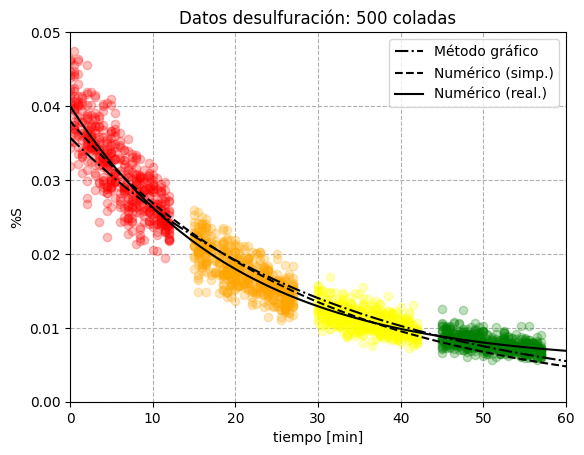

In [415]:
# visualización de los datos de proceso
fig, ax = plt.subplots()

unique_samples = pd.unique(df["sample"])
unique_colors = ["red", "orange", "yellow", "green"]
for sample, color in zip(unique_samples, unique_colors):
    dfr = df[df["sample"] == sample]
    ax.plot(dfr["t"], dfr["S"], ls='', marker='o', color=color, alpha=0.25)
ax.set(
    xlabel='tiempo [min]',
    ylabel='%S',
    xlim = (0, 60),
    ylim = (0, 0.05),
    title = f"Datos desulfuración: {nHeats} coladas"
)
ax.plot(t_eval, rate_law_1s(t_eval, k1, wS0), ls="-.", color='k', label='Método gráfico')
ax.plot(t_eval, rate_law_1s(t_eval, *paramsS), ls='--', color='k', label="Numérico (simp.)")
ax.plot(t_eval, rate_law_1r(t_eval, *paramsR), color='k', label="Numérico (real.)")
ax.grid(ls='--')
ax.legend(loc="upper right")
plt.show()

<center>

***¿Cuál modelo es más pertinente?***

</center>